In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [69]:
df=pd.read_csv("../data/raw/dos_icmp.csv",nrows=1000)

In [70]:
print ("Shape(rows,columns):",df.shape)

Shape(rows,columns): (1000, 85)


In [71]:
print("column length",len(df.columns))

column length 85


In [72]:
print(df.columns.tolist())

['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',

In [73]:
print (df['Label'].value_counts())

Label
1    1000
Name: count, dtype: int64


In [74]:
print(df['Attack Name'].value_counts())

Attack Name
DoS ICMP Flood    1000
Name: count, dtype: int64


In [75]:
df.sample(5)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
774,192.168.1.182-20.44.10.123-60550-443-6,192.168.1.182,60550,20.44.10.123,443,6,01/11/2023 10:38:38 AM,1053629,14,23,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,DoS ICMP Flood,1
433,3.220.73.162-192.168.1.172-443-53275-6,3.220.73.162,443,192.168.1.172,53275,6,01/11/2023 10:35:13 AM,12115,2,1,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,DoS ICMP Flood,1
963,192.168.1.9-13.226.34.4-63715-443-6,192.168.1.9,63715,13.226.34.4,443,6,01/11/2023 10:39:42 AM,45104109,4,4,...,3899.333333,671.617699,4643.0,3337.0,1.502971e+07,50816.169713,15088384.0,15000105.0,DoS ICMP Flood,1
766,192.168.1.9-192.168.1.1-8080-40417-6,192.168.1.9,8080,192.168.1.1,40417,6,01/11/2023 10:37:43 AM,45193520,4,4,...,206.666667,355.359442,617.0,1.0,1.506430e+07,45592.186012,15094764.0,15011884.0,DoS ICMP Flood,1
397,192.168.1.182-192.229.211.108-60492-80-6,192.168.1.182,60492,192.229.211.108,80,6,01/11/2023 10:34:48 AM,3806,1,1,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,DoS ICMP Flood,1


In [76]:
files = {
    "benign":      "../data/raw/benign.csv",
    "dos_icmp":    "../data/raw/dos_icmp.csv",
    "dos_syn":     "../data/raw/dos_syn.csv",
    "brute_force": "../data/raw/brute_force.csv",
    "port_scan":   "../data/raw/port_scan.csv",
}

parts=[]
for name,path in files.items():
    temp=pd.read_csv(path,nrows=20000)

    parts.append(temp)

    print(f"{name}:{temp.shape[0]} rows loaded")

benign:20000 rows loaded
dos_icmp:1405 rows loaded
dos_syn:15243 rows loaded
brute_force:18151 rows loaded
port_scan:20000 rows loaded


In [77]:
df_all = pd.concat(parts, ignore_index=True)
print ("Full concatinated Table:",df_all.shape)

Full concatinated Table: (74799, 85)


In [78]:
print("Label distribution:")
print(df_all['Label'].value_counts())

Label distribution:
Label
1    54799
0    20000
Name: count, dtype: int64


In [79]:
print(f"Attack name distribution:{df_all['Attack Name'].value_counts()}")

Attack name distribution:Attack Name
Benign Traffic            20000
Recon Port Scan           20000
Dictionary Brute Force    18151
DoS SYN Flood             15243
DoS ICMP Flood             1405
Name: count, dtype: int64


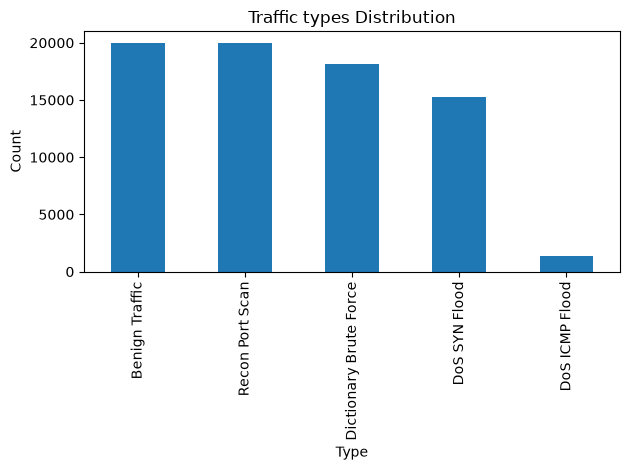

In [80]:
df_all['Attack Name'].value_counts().plot(kind='bar')
plt.title("Traffic types Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [81]:
drop_cols=['Flow ID','Src IP','Dst IP','Timestamp','Src Port','Dst Port']
df_all=df_all.drop(columns=drop_cols, errors='ignore')
print("Columns:",df_all.shape[1])
print("Table:",df_all.shape)

Columns: 79
Table: (74799, 79)


In [82]:
print("Total NaN Values:",df_all.isnull().sum().sum())

Total NaN Values: 0


In [83]:
numeric_cols = df_all.select_dtypes(include=[np.number])
inf_count=np.isinf(numeric_cols).sum().sum()
print("Total Infinity Value:",inf_count)

Total Infinity Value: 0


In [84]:
text_cols = df_all.select_dtypes(include=['object']).columns.tolist()
print("Text columns:", text_cols)

Text columns: ['Attack Name']


C:\Users\lenovo-pc\AppData\Local\Temp\ipykernel_21960\3464195007.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df_all.select_dtypes(include=['object']).columns.tolist()


In [85]:
for col in text_cols:
    print(f"\n{col} -> {df_all[col].nunique()} unique values")


Attack Name -> 5 unique values


In [86]:
from sklearn.preprocessing import LabelEncoder
# LabelEncoder har alag naam ko ek number de deta hai
le = LabelEncoder()
df_all['attack_code']=le.fit_transform(df_all['Attack Name'])

for name,code in zip(le.classes_, range(len(le.classes_))):
    print(f"{code}={name}")

0=Benign Traffic
1=Dictionary Brute Force
2=DoS ICMP Flood
3=DoS SYN Flood
4=Recon Port Scan


In [87]:
#target(0=normal,1=attack)
y=df_all['Label']

In [88]:
#features jisse identify krenge
X = df_all.drop(columns=['Label', 'attack_code', 'Attack Name'])

In [89]:
print("X (features) shape:", X.shape)
print("y (target) shape:", y.shape)

X (features) shape: (74799, 77)
y (target) shape: (74799,)


In [90]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=.2,
    random_state=442,
    stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nTrain labels:")
print(y_train.value_counts())
print("\nTest labels:")
print(y_test.value_counts())

Train: (59839, 77) | Test: (14960, 77)

Train labels:
Label
1    43839
0    16000
Name: count, dtype: int64

Test labels:
Label
1    10960
0     4000
Name: count, dtype: int64


In [91]:
# Random Forest model import kia hu
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

model.fit(X_train, y_train)
print("Model Trained")

Model Trained


In [92]:
y_pred=model.predict(X_test)

from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test, y_pred)
print(f"Accuracy:{acc*100: .2f}%")

Accuracy: 84.47%


In [93]:
# detailed report aur confusion matrix ke tools
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Attack (1)']))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

  Normal (0)       0.71      0.72      0.71      4000
  Attack (1)       0.90      0.89      0.89     10960

    accuracy                           0.84     14960
   macro avg       0.80      0.80      0.80     14960
weighted avg       0.85      0.84      0.84     14960

Confusion Matrix
[[2865 1135]
 [1189 9771]]


In [94]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train,y_train)
print("Model Trained")

y_pred_xgb = xgb.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print(f"\nXGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Attack']))

Model Trained

XGBoost Accuracy: 85.02%
              precision    recall  f1-score   support

      Normal       0.71      0.75      0.73      4000
      Attack       0.91      0.89      0.90     10960

    accuracy                           0.85     14960
   macro avg       0.81      0.82      0.81     14960
weighted avg       0.85      0.85      0.85     14960



In [95]:
#sab features ko ek common range mein laata hai
from sklearn.preprocessing import StandardScaler

#scaler banao
scaler=StandardScaler()
#scaler ko sirf train data pe fit karo
#phir train aur test dono ko 'transform' karo
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaling Done")
print("Train Shape:", X_train_scaled.shape)
print("Test Shape:",X_test_scaled.shape)

Scaling Done
Train Shape: (59839, 77)
Test Shape: (14960, 77)


In [96]:
from sklearn.metrics import accuracy_score,classification_report

rf_scaled=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_scaled.fit(X_train_scaled, y_train)
rf_pred=rf_scaled.predict(X_test_scaled)
print("Random Forest (scaled)")
print(f"Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(classification_report(y_test, rf_pred, target_names=['Normal','Attack']))

Random Forest (scaled)
Accuracy: 84.77%
              precision    recall  f1-score   support

      Normal       0.71      0.72      0.72      4000
      Attack       0.90      0.89      0.90     10960

    accuracy                           0.85     14960
   macro avg       0.81      0.81      0.81     14960
weighted avg       0.85      0.85      0.85     14960



In [97]:
y_multi=df_all['attack_code']

#features wahi hai bas target change kia 
from sklearn.model_selection import train_test_split
Xm_train, Xm_test, ym_train,ym_test=train_test_split(
    X,y_multi,
    test_size=.2,
    random_state=42,
    stratify=y_multi
)

rf_multi=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(Xm_train,ym_train)
ym_pred=rf_multi.predict(Xm_test)
print("Trained")

from sklearn.metrics import accuracy_score,classification_report
target_names=['Benign','Brute Force','DoS ICMP','DoS SYN','Port Scan']
print(f"Accuracy:{accuracy_score(ym_test, ym_pred)*100:.2f}%")
print(classification_report(ym_test, ym_pred, target_names=target_names))

Trained
Accuracy:81.85%
              precision    recall  f1-score   support

      Benign       0.68      0.77      0.72      4000
 Brute Force       0.72      0.72      0.72      3630
    DoS ICMP       0.39      0.16      0.23       281
     DoS SYN       0.97      0.92      0.95      3049
   Port Scan       0.97      0.93      0.95      4000

    accuracy                           0.82     14960
   macro avg       0.75      0.70      0.71     14960
weighted avg       0.82      0.82      0.82     14960



In [98]:
#SMOTE-rare class ki nakli examples banata hai,balance k liye
from imblearn.over_sampling import SMOTE
smote=SMOTE(
    random_state=42
)
Xm_train_bal,ym_train_bal=smote.fit_resample(Xm_train,ym_train)
print("Before SMOTE:")
print(ym_train.value_counts().sort_index())

print("After SMOTE")
print(ym_train_bal.value_counts().sort_index())

Before SMOTE:
attack_code
0    16000
1    14521
2     1124
3    12194
4    16000
Name: count, dtype: int64
After SMOTE
attack_code
0    16000
1    16000
2    16000
3    16000
4    16000
Name: count, dtype: int64


In [99]:
rf_smote=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(Xm_train_bal,ym_train_bal)
print("Done")

ym_pred_smote=rf_smote.predict(Xm_test)

from sklearn.metrics import accuracy_score, classification_report
target_names = ['Benign','Brute Force','DoS ICMP','DoS SYN','Port Scan']
print(f"Accuracy: {accuracy_score(ym_test, ym_pred_smote)*100:.2f}%")
print(classification_report(ym_test, ym_pred_smote, target_names=target_names))

Done
Accuracy: 80.64%
              precision    recall  f1-score   support

      Benign       0.70      0.73      0.71      4000
 Brute Force       0.72      0.71      0.72      3630
    DoS ICMP       0.16      0.34      0.22       281
     DoS SYN       0.97      0.92      0.94      3049
   Port Scan       0.98      0.92      0.95      4000

    accuracy                           0.81     14960
   macro avg       0.71      0.72      0.71     14960
weighted avg       0.82      0.81      0.81     14960



In [100]:
#model k decision ko explain krta hai SHAP
import shap
#sirf 500 testcases le re
X_sample=Xm_test[:500]

#TreeExplainer-Random forest like tree models
explainer=shap.TreeExplainer(rf_multi)
shap_values=explainer.shap_values(X_sample)

#in 500 rows k liye SHAP value nikalo(har feature ka role)
print("SHAP values type:",type(shap_values))

SHAP values type: <class 'numpy.ndarray'>


In [101]:
# summary plot ke liye — pehle SHAP values ka shape dekhte hain
print("Shape:", shap_values.shape)

Shape: (500, 77, 5)


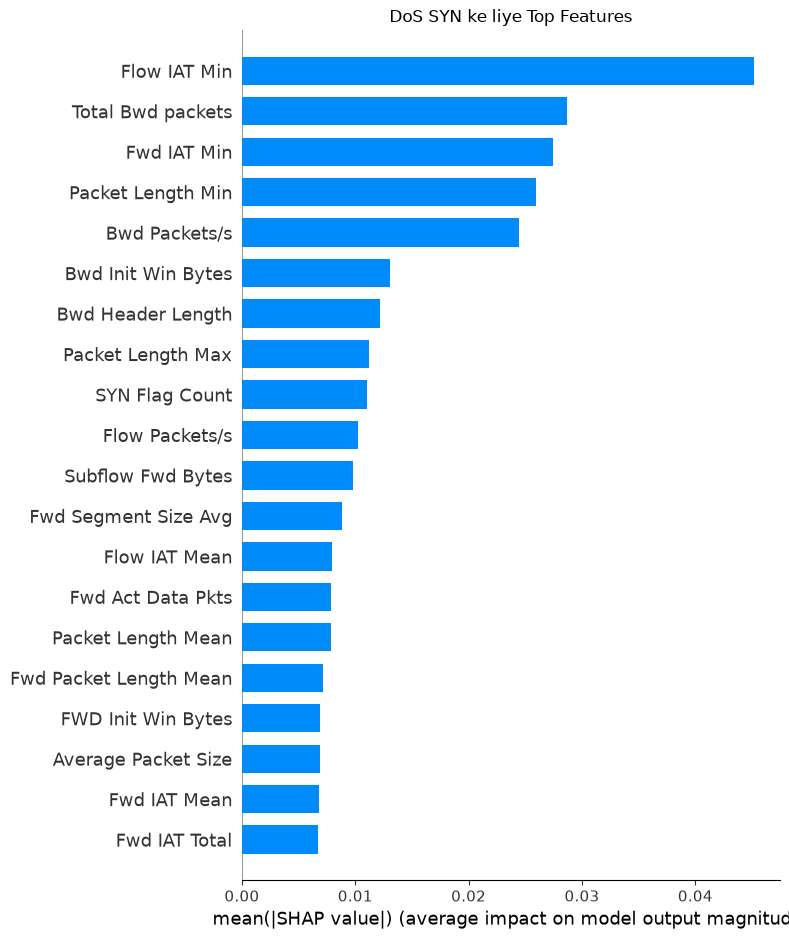

In [102]:
features_names=X.columns.tolist()

# class 3 = DoS SYN. uska SHAP data nikaalo
# shape (500, 77, 5) hai -> [:, :, 3] matlab "saare rows, saare features, class 3"
shap_class3 = shap_values[:, :, 3]
#summary plot banao- konse features class "DOS SYN" k liye important
import matplotlib.pyplot as plt
shap.summary_plot(
    shap_class3,
    X_sample,
    feature_names=features_names,
    plot_type="bar",
    show=False
)
plt.title("DoS SYN ke liye Top Features")
plt.tight_layout()
plt.show()

In [103]:
#check: if they are in memory or not ?
needed=["rf_multi", "rf_smote", "Xm_test", "ym_test", "model", "xgb"]
for item in needed:
    print(f"{item}:{'yes'if item in dir() else 'NO'}")

rf_multi:yes
rf_smote:yes
Xm_test:yes
ym_test:yes
model:yes
xgb:yes


In [104]:
# multi-class model dobara — taaki ym_pred fresh ho (purana overwrite ho gaya tha)
ym_pred = rf_multi.predict(Xm_test)

# turant accuracy check
from sklearn.metrics import accuracy_score
print("RF Multi-class accuracy (fresh):", round(accuracy_score(ym_test, ym_pred), 3))

RF Multi-class accuracy (fresh): 0.819


In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
import pandas as pd

#har model ka result nikal ra
def get_score(name, y_true, y_pred):
    return{
    "Model":name,
    "Accuracy":round(accuracy_score(y_true, y_pred),3), #tells kitna % sahi hai
    "Precision":round(precision_score(y_true, y_pred, average='weighted',zero_division=0),3),
    "Recall":round(recall_score(y_true, y_pred, average='weighted',zero_division=0),3),
    "F1":round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 3),
    }

#har model ka result ek list mein karo
results=[
    get_score("RF Binary", y_test, y_pred),
    get_score("XGBoost Binary",y_test,y_pred_xgb),
    get_score("Rf multi class",ym_test, ym_pred),
    get_score("Rf multi+ SMOTE",ym_test,ym_pred_smote),
]
results_df=pd.DataFrame(results)
print(results_df)


             Model  Accuracy  Precision  Recall     F1
0        RF Binary     0.845      0.845   0.845  0.845
1   XGBoost Binary     0.850      0.853   0.850  0.852
2   Rf multi class     0.819      0.822   0.819  0.819
3  Rf multi+ SMOTE     0.806      0.824   0.806  0.814


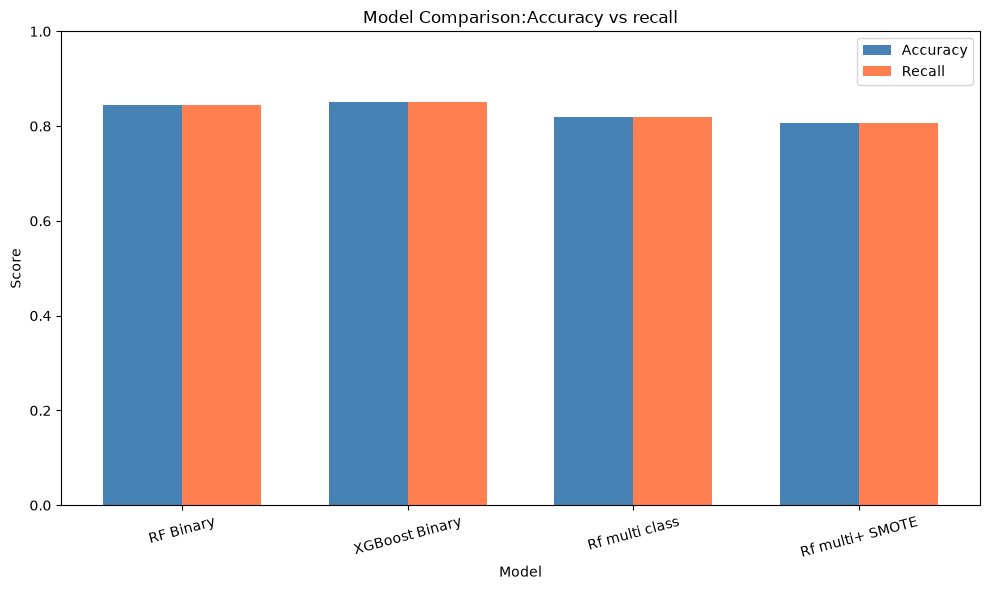

Graph save ho gya results/folder mein


In [112]:
import matplotlib.pyplot as plt
#table se data lere
models=results_df['Model']
accuracy=results_df['Accuracy']
recall=results_df['Recall']
#do BAR saath saath dikhane k liye position set kro
import numpy as np 
x=np.arange(len(models)) #har model ki position
width=0.35
 #graph bnao
fig, ax =plt.subplots(figsize=(10,6)) #graph size

# accuracy ke bars (left side)
ax.bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue')
# recall ke bars (right side)
ax.bar(x + width/2, recall, width, label='Recall', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison:Accuracy vs recall')
ax.set_xticks(x)
ax.set_xticklabels(models,rotation=15)
ax.legend()
ax.set_ylim(0,1)
plt.tight_layout()

#graph ko file mein save bhi karo
plt.savefig('../results/model_comparison.png',dpi=150,bbox_inches='tight')
plt.show()
print("Graph save ho gya results/folder mein")



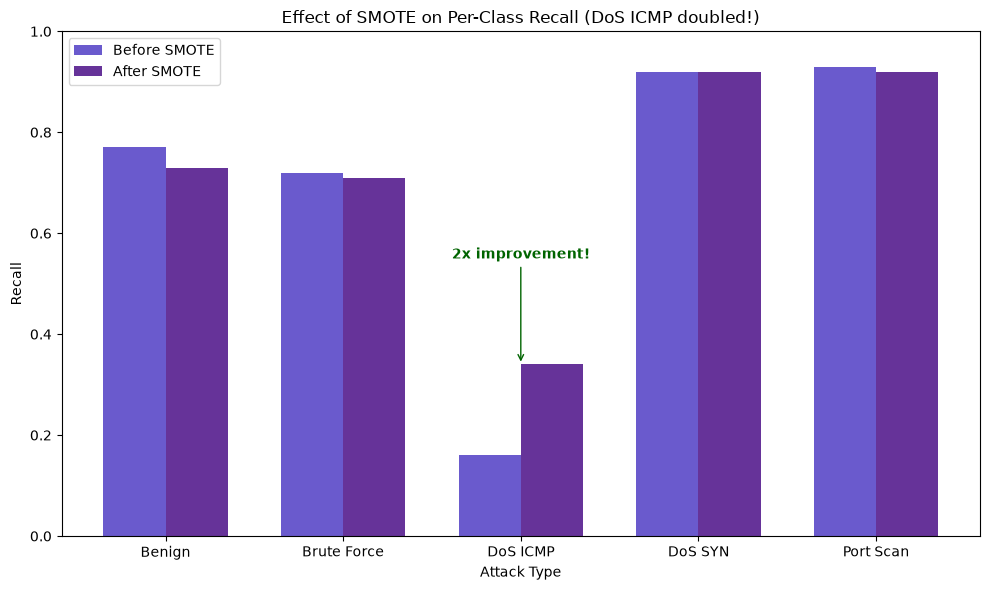

Graph 2 saved


In [124]:
import matplotlib.pyplot as plt

#har attack ka recall- smote se pehle aur baad mein 
classes=['Benign', 'Brute Force', 'DoS ICMP', 'DoS SYN', 'Port Scan']
recall_before = [0.77, 0.72, 0.16, 0.92, 0.93]
recall_after  = [0.73, 0.71, 0.34, 0.92, 0.92]

import numpy as np
x=np.arange(len(classes))

fig, ax= plt.subplots(figsize=(10,6))
ax.bar(x-width/2,recall_before,width,label='Before SMOTE', color='slateblue')
ax.bar(x+width/2,recall_after,width,label='After SMOTE', color='rebeccapurple')

ax.set_xlabel('Attack Type')
ax.set_ylabel('Recall')
ax.set_title('Effect of SMOTE on Per-Class Recall (DoS ICMP doubled!)')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.set_ylim(0, 1)

# DoS ICMP ke upar arrow/note (highlight karo)
ax.annotate('2x improvement!', xy=(2, 0.34), xytext=(2, 0.55),
            ha='center', color='darkgreen', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkgreen'))

plt.tight_layout()
plt.savefig('../results/smote_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph 2 saved")

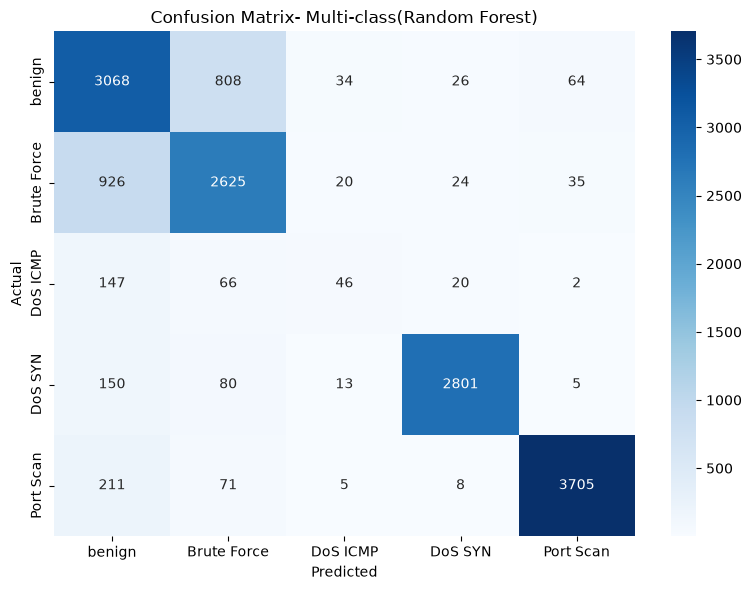

graph 3 saved


In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix #confursion matrix banane k liye

cm=confusion_matrix(ym_test,ym_pred)
#row=real class, column=model ne kya bola

classes=['benign','Brute Force', 'DoS ICMP','DoS SYN','Port Scan']

#heatmap banare
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes,
            ax=ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix- Multi-class(Random Forest)")

plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("graph 3 saved")